## 📌 **Informe de Laboratorio - Practica2**
  ###  Curva I–V de LEDs usando ESP32 (MicroPython) y LabVIEW

        Laboratorio Avanzado I


### 👥 **Integrantes del grupo:**

- Cristian Vergara
- Francesco Luligo
- Juan Jose Palacio
- Sofia Moscoso

---

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## **Resumen**
En esta actividad, se midieron las curvas Corriente -Voltaje de leds de diferentes longitudes de onda armados en un circuito sencillo, mediante la implementacion del microcontrolador ESP32 como procesador para automatizar procesos de medicion y el registro de datos en LabView. Tuvimos como objetivo, al medir la curva I–V de los LEDs rojo, verde y azul, calcular el voltaje umbral (Vf), comparar entre colores y analizar las propiedades físicas del DIODO y la resistencia dinámica, corroborando la ecuación del diodo y obteniendo el significado de las variables.


## **Introducción**
Un diodo es un componente electrónico semiconductor que permite el paso de la corriente eléctrica en un solo sentido, bloqueando el flujo en la dirección contraria. Está formado por la unión de dos regiones de material semiconductor: una tipo P (con huecos como portadores mayoritarios) y una tipo N (con electrones libres). Cuando se aplica una tensión positiva al ánodo (polarización directa), los portadores se recombinan en la zona de unión y el diodo conduce corriente; si la tensión se invierte (polarización inversa), la barrera de potencial se ensancha y la corriente prácticamente se anula. En los diodos LED (Light Emitting Diode), durante la polarización directa se produce emisión de luz como resultado de la recombinación electrón-hueco: la energía liberada se emite en forma de fotones. El color de la luz depende del material semiconductor y de la energía de la banda.

La gráfica corriente vs voltaje (I–V) del LED muestra un comportamiento no lineal característico:

En la región de polarización inversa, la corriente es casi nula (salvo una pequeña corriente de fuga). A partir de cierta tensión umbral o tensión de encendido (típicamente entre 1.6 V y 3.5 V, según el color del LED), la corriente aumenta bruscamente con pequeños incrementos de voltaje. Después del umbral, la relación entre corriente y voltaje es exponencial, lo que refleja la naturaleza del transporte de carga en el semiconductor.

Estas curvas son fundamentales para el diseño y uso de LEDs, pues no solo describen el comportamiento eléctrico, sino que también es una herramienta esencial para comprender su funcionamiento óptico y garantizar un uso seguro y eficiente en circuitos electrónicos, ya que permiten determinar la tensión mínima necesaria para encender el dispositivo,establecer los límites de corriente segura, evitando sobrecorrientes que dañen el LED,comparar el comportamiento eléctrico de distintos tipos de diodos y colores y analizar la eficiencia luminosa y el consumo energético del componente.



## **Procedimiento:**  
1. Se construyo el circuito necesario para la toma de datos.
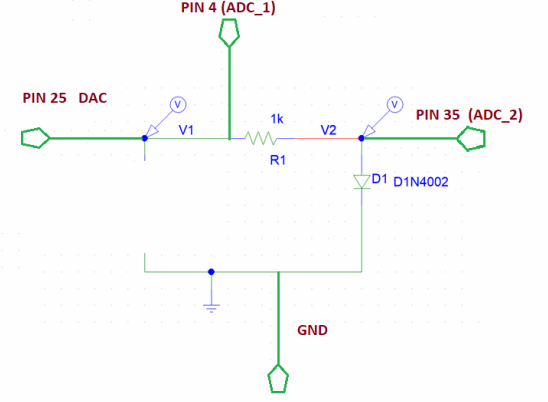

2. Construimos el codigo en microphyton(MU), el cual, configura el microcontrolador ESP32 para medir señales analógicas a través de dos pines ADC para el voltaje en distintos puntos del circuito,que nos permitieron calular posteriormente de forma directa, la corriente en los diodos. Se almacenan los datos y se envian al computador, a la plataforma labview cuando el usuario lo indique. El ESP32 usa un LED y un pin de control (“pulso”) como indicadores del estado del proceso de medición.


3. Construimos el diagrama necesario en LabView para que registre los datos ingresados de forma correcta en la comunicacion serial. Se grafico corriente en el diodo (eje y) versus voltaje en el diodo (eje x) en el visualizador de la plataforma.

4. Guardamos los datos obtenidos para realizar un analisis mas detallado en Phyton.


##Codigo en MU
Codigo que describe las "acciones" que realizara el microcontrolador ESP32 sobre el circuito sencillo que contiene el diodo led. Ademas, define las variables que seran medidas y almacenadas en el espacio de memoria del ESP32. Esta diseñado de modo que el programa inicie cuando se lo indique el usuario, tenga como salida un voltaje de 3,3V, tome medidas en un determinado intervalo de tiempo que sera escogido segun los parametros del sistema, en nuestro caso, este fue de 100ms,en dos puntos distintos de voltaje y termine al tomar una cantidad N de datos. Esta realizado para MU. no funciona en este colab.

In [ ]:
from machine import Pin, ADC , DAC
import time
import sys
import select

In [ ]:
led = Pin(2, Pin.OUT)

adc_1 = ADC(Pin(4))
adc_1.atten(ADC.ATTN_11DB)
adc_1.width(ADC.WIDTH_12BIT)

adc_2 = ADC(Pin(35))
adc_2.atten(ADC.ATTN_11DB)
adc_2.width(ADC.WIDTH_12BIT)

dac_v = DAC(Pin(25))

N = 255
R = 1000

while True:
  if sys.stdin in select.select([sys.stdin], [], [], 0)[0]:

    c = sys.stdin.read(1)
    if c == 'a':
      led.on()

      for i in range(N):
        dac_v.write(i)
        time.sleep_ms(100)
        V1 = adc_1.read()
        V2 = adc_2.read()

        V = V1 * 3.3 / 4095.0
        Vd = V2 * 3.3 / 4095.0

        Id = (V1 - V2) * (1000.0 / R) * (3.3 / 4095.0)

        print(Id, Vd, sep=';')
        print('FIN')
        led.off()

    else:
      led.off()

##Diagrama LabView
El programa en labview, se inicia definiendo el puerto serial, verifica si hay o no un error en la comunicación serial, posteriormente abre un archivo para ingresar los datos cuando el usuario envie el carácter ‘a’, el cual, inicia la medida y lee los datos mediante un While, generando dos array numéricos para almacenar los valores de corriente
y voltaje (shift registers). Ademas,  verifica si hay datos en el buffer, si el numero de estos es mayor que cero, es decir hay datos en el puerto,
entonces se deben leer los datos, case True. Cuando la palabra que llegó por el serial es “FIN”  se termina el while loop. Mientras no haya llegado este string al serial de labview, entonces las
medidas de la forma “corriente;voltaje”, que están
separadas por un punto y coma “;”, se continuan almacenando.
Por ultimo, se crea un indicador para poder ver los valores desde el panel, graficando los datos.


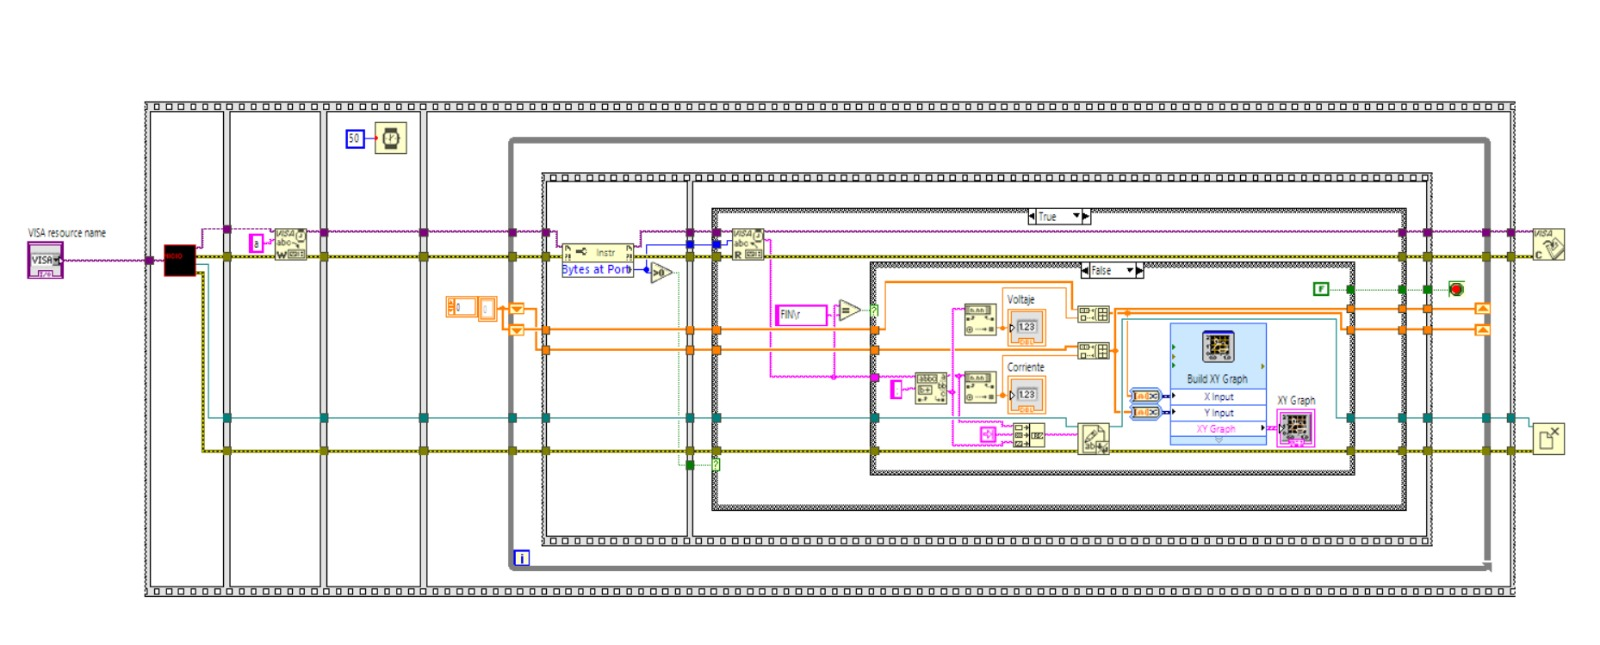





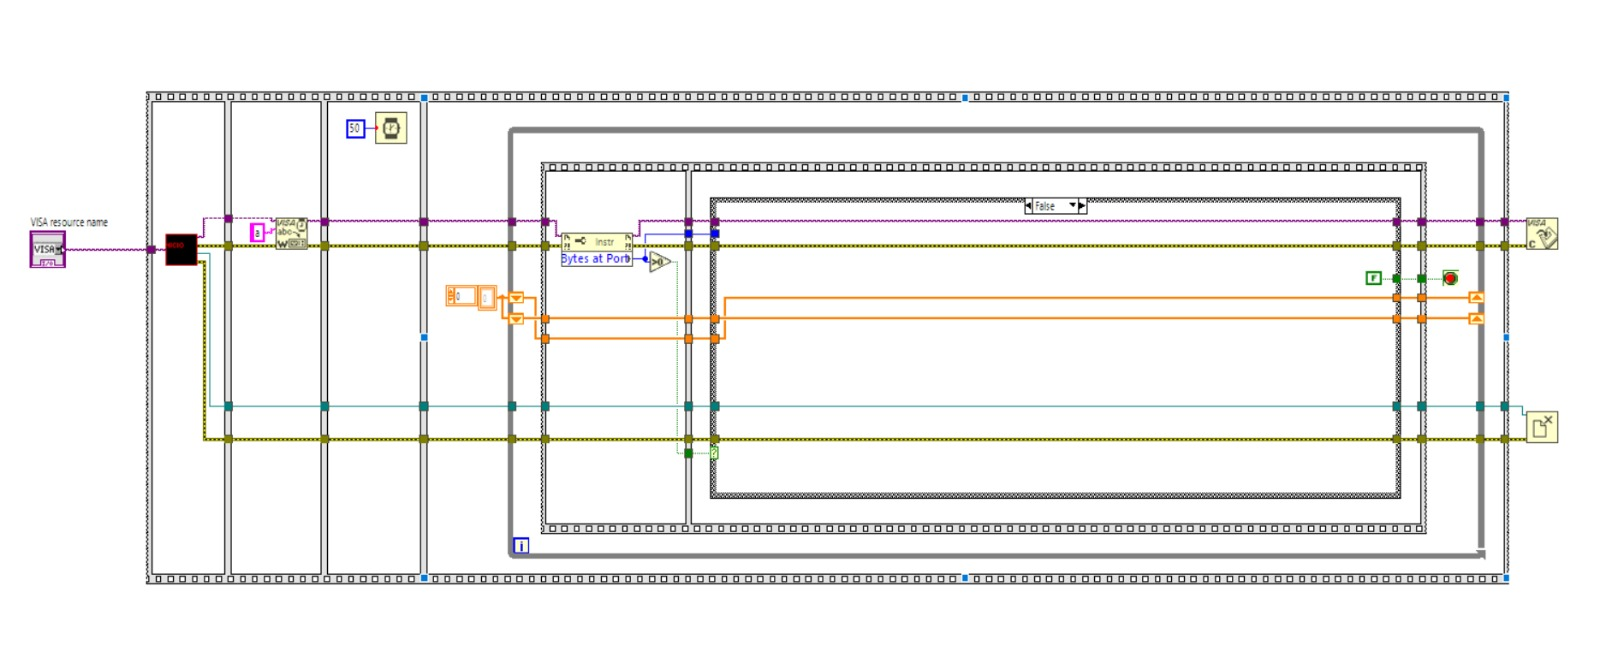

##Analisis Datos


In [ ]:
azul = pd.read_csv( '/content/azul.txt', skiprows=6, delim_whitespace=True, encoding='latin1')
rojo = pd.read_csv('/content/rojo.txt', skiprows=6, delim_whitespace=True, encoding='latin1')
verde = pd.read_csv('/content/verde.txt', skiprows=6, delim_whitespace=True, encoding='latin1')

azul.rename(columns={'0.0': 'Corriente(mA)'}, inplace=True)
rojo.rename(columns={'0.0': 'Corriente(mA)'}, inplace=True)
verde.rename(columns={'0.0': 'Corriente(mA)'}, inplace=True)

azul.rename(columns={'0.0.1': 'Voltaje(v)'}, inplace=True)
rojo.rename(columns={'0.0.1': 'Voltaje(v)'}, inplace=True)
verde.rename(columns={'0.0.1': 'Voltaje(v)'}, inplace=True)

Interpolamos los datos para obtener una curva fina e ignorar el ruido en la medicion.

In [ ]:
blue = np.polyfit(azul["Voltaje(v)"], azul["Corriente(mA)"], deg =10)
blue = np.poly1d(blue)
red = np.polyfit(rojo["Voltaje(v)"], rojo["Corriente(mA)"], deg=10)
red = np.poly1d(red)
green = np.polyfit(verde["Voltaje(v)"], verde["Corriente(mA)"] , deg =10)
green = np.poly1d(green)

v= np.linspace(0, 3.3, 100)

plt.plot(azul["Voltaje(v)"], azul["Corriente(mA)"], 'o', c = "#8AE9EB")
plt.plot(rojo["Voltaje(v)"], rojo["Corriente(mA)"], 'o', c = "#EB9A8A")
plt.plot(verde["Voltaje(v)"], verde["Corriente(mA)"], 'o', c = "#8CEB8A")

plt.plot(v , blue(v), '-', c = "blue", label='Led Azul')
plt.plot(v , red(v), '-', c = "red", label='Led Rojo')
plt.plot(v , green(v), '-', c = "green", label='Led Verde')

plt.title('IvsV')
plt.xlabel('Voltaje(v)')
plt.ylabel('Corriente(mA)')
plt.grid(True)
plt.legend()
plt.show()

El voltaje umbral Vf se encuentra en el minimo de la curva, de modo que hayamos las derivadas de la funcion obtenida al interpolar para obtener el punto critico.

In [ ]:
v_dense = np.linspace(1, 3.3, 2000)

d_blue = np.polyder(blue)(v_dense)
d_red  = np.polyder(red)(v_dense)
d_green = np.polyder(green)(v_dense)

# primera vez que la derivada pasa cierto valor
thr_b = 0.2 * np.max(d_blue)
V_umbral_blue = v_dense[np.where(d_blue > thr_b)[0][0]]

thr_r = 0.2 * np.max(d_red)
V_umbral_red = v_dense[np.where(d_red > thr_r)[0][0]]

thr_g = 0.2 * np.max(d_green)
V_umbral_green = v_dense[np.where(d_green > thr_g)[0][0]]

print("Umbral azul =", round(V_umbral_blue,2))
print("Umbral rojo =", round(V_umbral_red,2))
print("Umbral verde =", round(V_umbral_green,2))


Las propiedades físicas del DIODO se estudian a travez de su ecuación:
$$
I = I_s \left( e^{\frac{V}{n _V T}} - 1 \right)
$$
hayamos entonces las variables fisicas que la definen mediante una interpolacion lineal de las curvas.

- $I_s$: corriente de saturación inversa,el cual depende del material y de la temperatura.
- $n$: factor de idealidad del diodo.Indica qué tan ideal es el diodo, los LEDs suelen tener n entre 1.5 y 2.5
- $V_T$: voltaje termico, correspondente a
$$
V_T= {\frac{kT}{q}}
$$

- $q$: carga del electrón,
- $T$: temperatura absoluta,
- $k$: Constante de Boltzman


In [ ]:
def parametros(voltaje, corriente):
# --- 1. Cargar datos experimentales ---
  V = voltaje
  I = corriente
# --- 2. Seleccionar la región exponencial ---
  mask = I > 0.0005
  V_fit = V[mask]
  I_fit = I[mask]
# --- 3. Ajustar ln(I) vs V ---
  lnI = np.log(I_fit)
  m, b = np.polyfit(V_fit, lnI, 1)    # pendiente y intercepto
# --- 4. Extraer parámetros físicos ---
  nVT = 1 / m              # n * V_T
  Is = np.exp(b)           # corriente de saturación
  VT = 0.0258              # voltaje térmico a 25°C
  n = nVT / VT             # factor de idealidad
  print(f"voltaje termico: {VT}, Corriente de Saturacion: {Is}, Factor de Idealidad: {n}")
  return [ Is ,VT ,n]

In [ ]:
print(f"""para
rojo   {parametros(rojo["Voltaje(v)"], rojo["Corriente(mA)"])}
verde {parametros(verde["Voltaje(v)"], verde["Corriente(mA)"])}
azul {parametros(azul["Voltaje(v)"], azul["Corriente(mA)"])} """)

Observamos que los voltajes termicos tienen el mismo valor correspondiente a 0.0258 en los tres diodos led. Este representa la energía térmica promedio que poseen las cargas (electrones) en un semiconductor debido a la temperatura. Tiene sentido que tengan el mismo valor debido a que los datos fueron tomados el mismo dia a una diferencia no muy grande de tiempo, por lo que no hubo una variacion considerable en la temperatura, ademas K y q son constantes.

Por otro lado, los factores de idealidad tienen un valor bastante grande, que aumenta desde el rojo hasta el azul, lo que implica que los diodos leds usados se alejan bastante de comportamiento ideal, hay efectos adicionales no ideales como: resistencias serie grandes e imperfecciones del semiconductor.

La corriente de Saturacion, por el contrario, presenta un valor diferente no ordinal para cada led. Esta es la pequeña corriente que fluye cuando el diodo está polarizado inversamente y se debe a la generación térmica de pares electrón-hueco. Aunque en teoría no debería haber corriente con polarización inversa, en la práctica se presenta una fuga de corriente muy pequeña y prácticamente constante. El azul entonces tiene una fuga de corriente mayor a la del verde y el rojo.

Verifiquemos los datos encntrados visualmente:

In [ ]:
def ecuacion(x,y):
  D = parametros(x,y)
  Is = D[0]
  VT = D[1]
  n = D[2]
  I = Is*(np.exp(v/(n*VT))-1)
  return I

In [ ]:
plt.plot(azul["Voltaje(v)"], azul["Corriente(mA)"], 'o', c = "#8AE9EB" , label ="azul experimental")
plt.plot(rojo["Voltaje(v)"], rojo["Corriente(mA)"], 'o', c = "#EB9A8A" ,label ="rojo experimental")
plt.plot(verde["Voltaje(v)"], verde["Corriente(mA)"], 'o', c = "#8CEB8A", label ="verde experimental")

plt.plot(v,ecuacion(azul["Voltaje(v)"], azul["Corriente(mA)"]), "-", c = "blue", label='Azul teorico')
plt.plot(v,ecuacion(verde["Voltaje(v)"], verde["Corriente(mA)"]), "-", c = "green", label='verde teorico')
plt.plot(v,ecuacion(rojo["Voltaje(v)"], rojo["Corriente(mA)"]), "-", c = "red", label='rojo teorico')

plt.title('IvsV')
plt.xlabel('Voltaje(v)')
plt.ylabel('Corriente(mA)')
plt.grid(True)
plt.legend()
plt.show()

La curva experimental aumenta más rápido que la predicción obtenida con los parámetros extraídos inicialmente. Esto indica que los parámetros
Is y nVT empleados no representan adecuadamente la región exponencial medida (probablemente por selección inadecuada de puntos o por ruido), y/o que hay efectos experimentales no contemplados.

La Resistencia Dinamica en el diodo define cuánta variación de voltaje produce una variación de corriente muy pequeña cerca de un punto de operación. Se define como:
$$
r_d = {\frac{dI}{dV}} = {\frac{nV_T}{I}}
$$

In [ ]:
def rd(x,y,I):
  D = parametros(x,y)
  VT = D[1]
  n = D[2]
  rd = n*VT/I
  return rd

In [ ]:
I=np.linspace(0,0.2,100)

plt.plot(I,rd(azul["Voltaje(v)"], azul["Corriente(mA)"]*100,I), "-", c = "blue", label='Azul')
plt.plot(I,rd(verde["Voltaje(v)"], verde["Corriente(mA)"]*100,I), "-", c = "green", label='verde')
plt.plot(I,rd(rojo["Voltaje(v)"], rojo["Corriente(mA)"]*100,I), "-", c = "red", label='rojo')

plt.title("rd vs I")
plt.xlabel('Corriente(A)')
plt.ylabel('Resistencia Dinamica (ohmios)')
plt.grid(True)
plt.legend()
plt.show()


La resistencia dinámica cae hiperbolicamente a medida que la corriente aumenta. Para corrientes muy pequeñas, la resistencia dinámica toma valores muy grandes, lo cual refleja que el diodo apenas conduce y se requiere un incremento significativo de voltaje para producir un pequeño cambio de corriente. Esta forma es exactamente la esperada teóricamente.

Las diferencias entre colores también tienen sentido: El LED azul muestra mayor resistencia dinámica debido a su mayor factor de idealidad y/o menor corriente efectiva en esa región. El rojo presenta la menor resistencia dinámica, lo cual concuerda con su menor voltaje de umbral y mayor pendiente exponencial.
El verde queda en un punto intermedio.

##Conclusion


In [ ]:
#Valores teoricos
VUblueT =2.8
VUgreenT = 2.0
VUredT = 1.6
#Valores Experimentales
Umbral_azul = 2.78
Umbral_verde = 2.01
Umbral_rojo = 1.56

def error(x,y):
  return round(abs(x - y)/x*100,2)

print(f"""porcentajes de error:
rojo: {error(VUredT,Umbral_rojo)}%
verde: {error(VUgreenT,Umbral_verde)}%
azul: {error(VUblueT,Umbral_azul)}%""")

Se midieron los voltajes umbral de tres LEDs: rojo 1.56 V, verde 2.01 V y azul 2.78 V. Estos valores siguen la relación esperada por la física de semiconductores, mayor bandgap (rango de energia para excitar los electrones) → mayor voltaje. El rojo requiere menor energia que el verde y el azul, debido a que tiene una frecuencia mas baja que los otros dos, reciprocamente, una longitud de onda mas alta. Los porcentajes de error obtenidos en la practica para la medida del voltaje umbral en los leds rojo, verde y azul fueron 2.5%, 0.5%, 0.7% respectivamente, los cuales son relativamente bajos.
Las pequeñas diferencias observadas se atribuyen a la elección del criterio de umbral (corriente de referencia), método de ajuste, ruido y efectos experimentales (resistencia serie, temperatura y tolerancias de fabricación).

La comparación entre los datos experimentales y las curvas teóricas obtenidas con la ecuación del diodo muestra que el modelo describe correctamente la tendencia general del comportamiento de los LEDs, pero no reproduce con exactitud la curva I–V.
Las coincidencias y discrepancias observadas pueden explicarse por las limitaciones del modelo ideal y por características físicas reales del dispositivo:
